# Import

In [66]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from collections import Counter
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV

# Open Datasets

In [2]:
df = pd.read_csv("eye_tracking_dataset_2.csv")

# lihat sekilas
print(df.head())
print(df["label"].value_counts())

   avg_velocity  max_velocity  std_velocity  total_distance  fixation_ratio  \
0      0.361968      1.253364      0.403662        3.979800        0.000000   
1      0.536203      1.626338      0.494673        5.549393        0.000000   
2      0.402936      2.437280      0.557468        4.184695        0.000000   
3      0.395435      1.546485      0.418128        4.101271        0.000000   
4      0.377066      1.664265      0.382938        3.911977        0.033333   

   unique_area_count                                       file   label  
0                  5  0ad2a13e-3b8c-47b4-a072-9efd53746165.json  sedang  
1                  6  0ad2a13e-3b8c-47b4-a072-9efd53746165.json  sedang  
2                  5  0ad2a13e-3b8c-47b4-a072-9efd53746165.json  sedang  
3                  5  0ad2a13e-3b8c-47b4-a072-9efd53746165.json  sedang  
4                  4  0ad2a13e-3b8c-47b4-a072-9efd53746165.json  sedang  
label
sedang    148
tinggi     56
normal     55
Name: count, dtype: int64


# Processing the Data

In [3]:
X = df.drop(columns=["file", "label"])
y = df["label"]

le = LabelEncoder()
y = le.fit_transform(y)

print(le.classes_)  # untuk cek mapping label

['normal' 'sedang' 'tinggi']


<Axes: xlabel='label', ylabel='avg_velocity'>

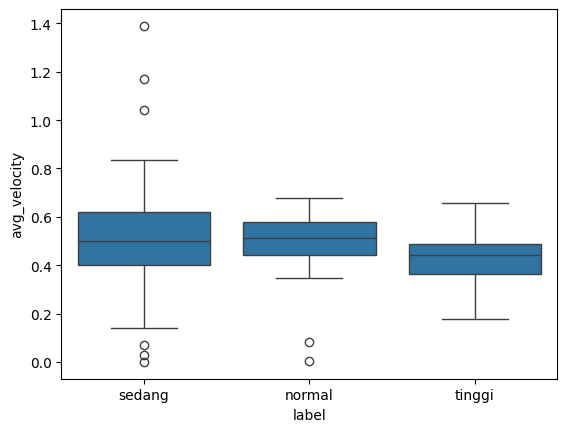

In [73]:
sns.boxplot(data=df, x='label', y='avg_velocity')

# Split Data

In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# smote = SMOTE(random_state=42)

# X_train_resampled, y_train_resampled = smote.fit_resample(
#     X_train,
#     y_train
# )

# gss = GroupShuffleSplit(test_size=0.3, random_state=42)
# groups = df["file"]

# for train_idx, test_idx in gss.split(X, y, groups):
#     X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
#     y_train, y_test = y[train_idx], y[test_idx]

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Search the best tuning for SVM

In [118]:
param_grid = {
    'C': [0.1, 1, 10, 50],
    'gamma': ['scale', 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(
    SVC(class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='f1_macro'
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 50, 'gamma': 0.1, 'kernel': 'rbf'}
0.6156384963904145


In [119]:
best_model = grid.best_estimator_

In [120]:
print(type(best_model))
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", acc)
print(classification_report(y_test, y_pred))

<class 'sklearn.svm._classes.SVC'>
Test Accuracy: 0.6153846153846154
              precision    recall  f1-score   support

           0       0.43      0.82      0.56        11
           1       0.81      0.43      0.57        30
           2       0.67      0.91      0.77        11

    accuracy                           0.62        52
   macro avg       0.64      0.72      0.63        52
weighted avg       0.70      0.62      0.61        52



# Search the best tuning for RandomForestClassifier

In [114]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
0.5628053498321784


In [115]:
best_model = grid.best_estimator_

In [116]:
print(type(best_model))
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Test Accuracy:", acc)
print(classification_report(y_test, y_pred))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
Test Accuracy: 0.6346153846153846
              precision    recall  f1-score   support

           0       0.50      0.64      0.56        11
           1       0.72      0.60      0.65        30
           2       0.62      0.73      0.67        11

    accuracy                           0.63        52
   macro avg       0.61      0.65      0.63        52
weighted avg       0.65      0.63      0.64        52



# Training the models (SVM and RandomForestClassifier)

In [122]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42
)

In [83]:
model = SVC(
    kernel="rbf",   # bisa coba: linear / poly / rbf
    C=50,
    gamma=0.1,
    class_weight="balanced",
    probability=True
)

In [123]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [124]:
y_pred = model.predict(X_test)

# Result Model

In [125]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6346153846153846
              precision    recall  f1-score   support

           0       0.50      0.64      0.56        11
           1       0.72      0.60      0.65        30
           2       0.62      0.73      0.67        11

    accuracy                           0.63        52
   macro avg       0.61      0.65      0.63        52
weighted avg       0.65      0.63      0.64        52



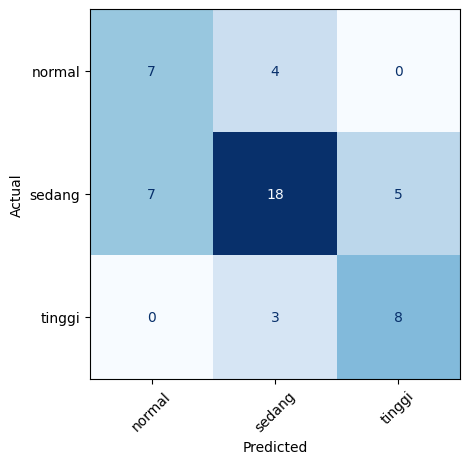

In [126]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

disp.plot(cmap=plt.cm.Blues, values_format="d", xticks_rotation=45, colorbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [127]:
feature_names = ['avg_velocity', 'max_velocity', 'std_velocity', 'total_distance', 'fixation_ratio', 'unique_area_count']
importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance)

             feature  importance
0       avg_velocity    0.197700
5  unique_area_count    0.186740
3     total_distance    0.180138
2       std_velocity    0.167756
1       max_velocity    0.146137
4     fixation_ratio    0.121529


# Save Model

In [128]:
joblib.dump(model, 'model/rfc_anxiety_model.pkl')

# pakai scaler:
joblib.dump(scaler, 'model/rfc_anxiety_scaler.pkl')

['model/rfc_anxiety_scaler.pkl']

In [129]:
# Load model dan scaler
model = joblib.load('model/rfc_anxiety_model.pkl')
scaler = joblib.load('model/rfc_anxiety_scaler.pkl')

In [130]:
feature_names = ['avg_velocity', 'max_velocity', 'std_velocity', 'total_distance', 'fixation_ratio', 'unique_area_count']

# Data mata dalam bentuk DataFrame
data_baru_df = pd.DataFrame([[0.3547990888851598,2.3653921589120412,0.5583986851058569,2.1474181470059315,0.058823529411764705,4]], columns=feature_names)

# Transform dengan scaler
data_baru_scaled = scaler.transform(data_baru_df)

# Prediksi
hasil = model.predict(data_baru_scaled)

hasil_akhir = Counter(hasil).most_common(1)[0][0]

# Tampilkan hasil
print("Prediksi Kecemasan:", hasil_akhir)

Prediksi Kecemasan: 2
